<a href="https://colab.research.google.com/github/RonakkudalAI/Data-Analysis/blob/main/HeartAttack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Heart_attack.csv")
df

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0,0,0,18,15,0,9,4,3
1,0,0,0,0,25.0,1,0,0,1,0,0,0,0,7,6,1
2,0,1,1,1,28.0,0,0,0,0,0,30,30,0,9,4,8
3,0,1,0,1,27.0,0,0,0,1,0,0,0,0,11,3,6
4,0,1,1,1,24.0,0,0,0,1,0,3,0,0,11,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129993,0,1,1,1,25.0,1,0,0,1,0,0,28,0,7,6,7
129994,0,0,0,1,27.0,0,0,0,0,0,0,0,0,9,6,8
129995,0,0,0,1,29.0,0,0,0,1,0,2,5,0,4,6,8
129996,0,0,0,0,21.0,0,0,0,1,0,0,5,0,4,6,8


In [ ]:
df.isnull().sum()

,0
HeartDiseaseorAttack,0
HighBP,0
HighChol,0
CholCheck,0
BMI,10
Smoker,0
Stroke,0
Diabetes,0
PhysActivity,0
HvyAlcoholConsump,0


In [ ]:
median_BMI = df['BMI'].median()
df['BMI'].fillna(median_BMI, inplace=True)
display(df['BMI'].isnull().sum())


/tmp/ipykernel_1095/2671939956.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BMI'].fillna(median_BMI, inplace=True)


np.int64(0)

In [ ]:
number_only = df.select_dtypes('int64','float64')

<Axes: >

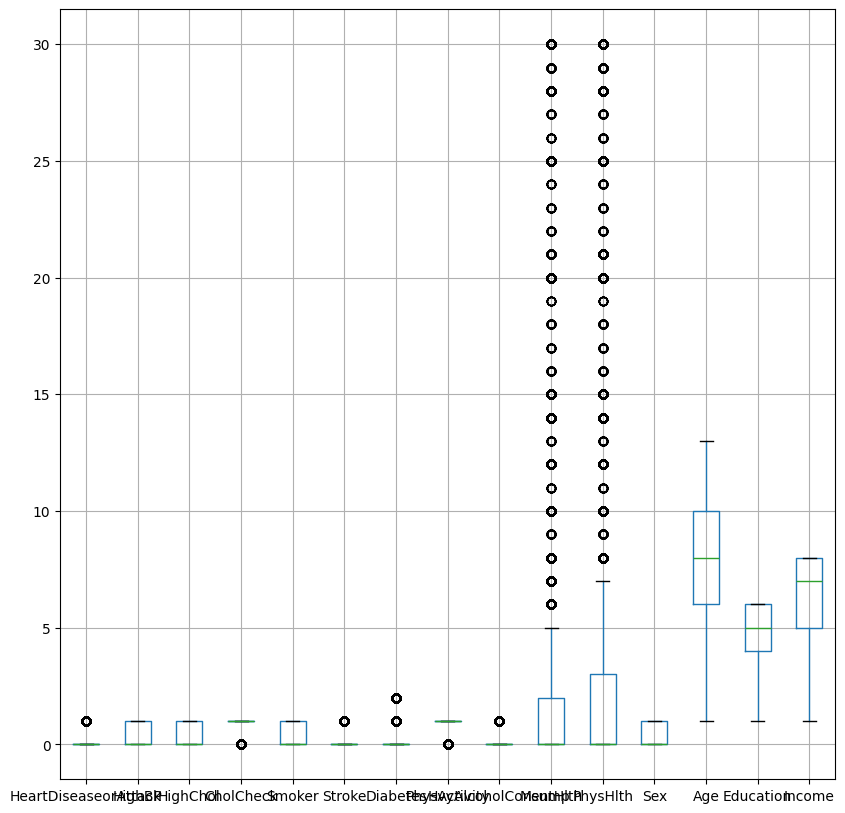

In [ ]:
plt.figure(figsize=(10,10))
number_only.boxplot()

In [ ]:
#outlier
Q1 = number_only.quantile(0.25)
Q3 = number_only.quantile(0.75)

In [ ]:
#IQR
IQR = Q3-Q1
lower_range = Q1-1.5*IQR
Upper_range = Q3+1.5*IQR

In [ ]:
df_clean = number_only[~((number_only<lower_range) | (number_only>Upper_range)).any(axis=1)]
print(df_clean)

        HeartDiseaseorAttack  HighBP  HighChol  ...  Age  Education  Income
3                          0       1         0  ...   11          3       6
4                          0       1         1  ...   11          5       4
5                          0       1         1  ...   10          6       8
7                          0       1         1  ...   11          4       4
15                         0       1         0  ...    6          6       8
...                      ...     ...       ...  ...  ...        ...     ...
129984                     0       0         0  ...    9          6       8
129987                     0       0         1  ...    7          6       8
129988                     0       0         0  ...   10          4       3
129992                     0       1         0  ...    3          4       7
129995                     0       0         0  ...    4          6       8

[58931 rows x 15 columns]


In [ ]:
#Corelatiom
df_corr = df_clean.corr()
df_corr

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
HeartDiseaseorAttack,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HighBP,NaN,1.000000,0.226384,NaN,0.082036,NaN,NaN,NaN,NaN,-0.033195,0.042759,0.053453,0.308264,-0.090532,-0.102090
HighChol,NaN,0.226384,1.000000,NaN,0.071008,NaN,NaN,NaN,NaN,-0.003911,0.037721,0.035481,0.265775,-0.016916,-0.015985
CholCheck,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smoker,NaN,0.082036,0.071008,NaN,1.000000,NaN,NaN,NaN,NaN,0.002950,0.021000,0.077741,0.139464,-0.148828,-0.093213
Stroke,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diabetes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhysActivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HvyAlcoholConsump,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MentHlth,NaN,-0.033195,-0.003911,NaN,0.002950,NaN,NaN,NaN,NaN,1.000000,0.107773,-0.079948,-0.155622,0.025145,-0.020530


In [ ]:
# sns.heatmap(df_corr,annot=True)

NameError: name 'y_test' is not defined